# Analyzing the gradients of the SHT

## Setup

In [9]:
import torch
import torch.nn as nn

from tqdm.auto import tqdm

from torch_harmonics.quadrature import legendre_gauss_weights, clenshaw_curtiss_weights
from torch_harmonics import RealSHT, InverseRealSHT
from torch_harmonics.utils import load_mola_elevation

## Problem setting

We consider the simple problem of fitting the spectral coefficients $\theta$ such that

$$
\begin{aligned}
\mathcal{L}
&= ||\mathop{\mathrm{ISHT}}[\theta] - u^*||^2_{S^2} \\
&\approx \sum_j \omega_j (\mathop{\mathrm{ISHT}}[\theta](x_j) - u^*(x_j))^2 \\
&= (S \, \theta - u^*)^T \mathop{\mathrm{diag}}(\omega) \, (S \, \theta - u^*) \\
&= L
\end{aligned}
$$

is minimized.

The Vandermonde matrix $S$, which is characterized by $\mathop{\mathrm{ISHT}}[\theta] = S \theta$ realizes the action of the discrete SHT.

The necessary condition for a minimizer of $L$ is

$$
\begin{aligned}
& \nabla_\theta L = S^T \mathop{\mathrm{diag}}(\omega) \, (S \, \theta - u^*) = 0 \\
\Leftrightarrow \quad & S^T \mathop{\mathrm{diag}}(\omega) \, S \; \theta = S^T \mathop{\mathrm{diag}}(\omega) \, u^*.
\end{aligned}
$$

On the Gaussian grid, 

In [10]:
nlat = 64
nlon = 2*nlat
grid = "equiangular"

# for quadrature and plotting
if grid == "legendre-gauss":
    lmax = mmax = nlat
    xq, wq = legendre_gauss_weights(nlat)
elif grid =="equiangular":
    lmax = mmax = nlat//2
    xq, wq = clenshaw_curtiss_weights(nlat)

sht = RealSHT(nlat, nlon, lmax=lmax, mmax=mmax, grid=grid)
isht = InverseRealSHT(nlat, nlon, lmax=lmax, mmax=mmax, grid=grid)

lat = torch.arccos(xq)
omega = torch.pi * wq.float() / nlat
omega = omega.reshape(-1, 1)

print(nlon*omega.sum())

tensor(12.5664)


## analytic  gradients of the SHT

In [11]:
data = load_mola_elevation(nlat, nlon)

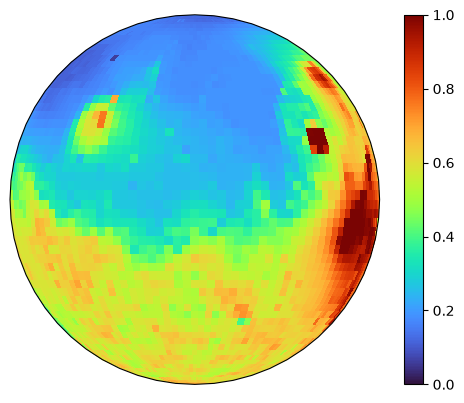

In [12]:
import matplotlib.pyplot as plt
from torch_harmonics.plotting import plot_sphere

plot_sphere(data, projection="orthographic", cmap="turbo", colorbar=True)

the analytic gradients are of the discrete SHT can be determined using some linear algebra. If the analysis step is $\theta = S^\dagger \mathop{\mathrm{diag}}(\omega) u$, we can determine that $J_u \theta = \mathop{\mathrm{diag}}(\omega) S$. 

In [13]:
torch.manual_seed(333)

u = data.clone()
u.requires_grad_(True)

theta = sht(u)

# direction for backward pass
gin = torch.randn_like(theta, requires_grad=False)

# gradient computed using autodiff
theta.backward(gin)

# print(u.grad)

# analytic gradient computed using ISHT
mweights = torch.ones(1, gin.shape[-1], dtype=gin.dtype)
mweights[..., 1:] *= 0.5
ugrad = omega * isht(mweights * gin)

(u.grad - ugrad) / u.grad.max().abs()

tensor([[ 1.0361e-09,  1.0361e-09,  1.0361e-09,  ...,  1.0361e-09,
          1.0361e-09,  1.0361e-09],
        [-3.3155e-09, -3.3155e-09, -6.6309e-09,  ..., -6.6309e-09,
         -6.6309e-09, -3.3155e-09],
        [ 0.0000e+00,  1.3262e-08,  1.3262e-08,  ...,  1.3262e-08,
          0.0000e+00,  2.6524e-08],
        ...,
        [ 0.0000e+00,  6.6309e-09,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  6.6309e-09],
        [ 3.3155e-09,  3.3155e-09,  3.3155e-09,  ...,  3.3155e-09,
          3.3155e-09,  3.3155e-09],
        [-2.0722e-10, -2.0722e-10, -2.0722e-10,  ..., -2.0722e-10,
         -2.0722e-10, -2.0722e-10]])

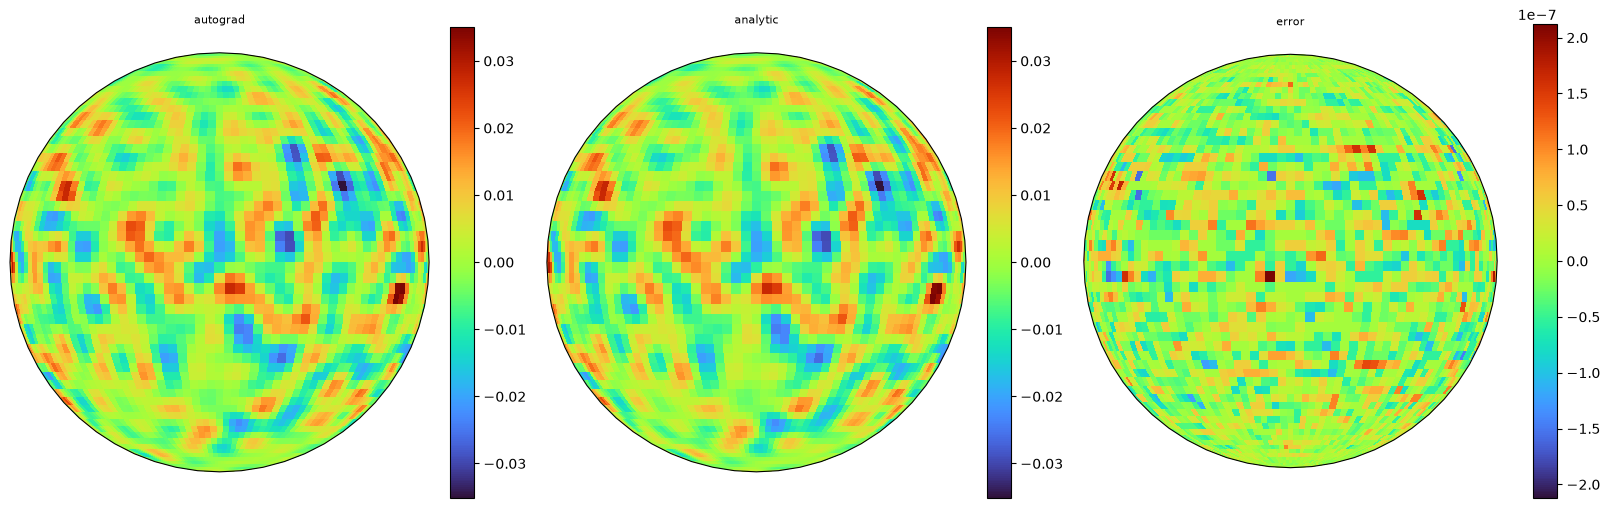

In [14]:
fig = plt.figure(figsize=(16, 5), layout='constrained')
subfigs = fig.subfigures(1, 3)

plot_sphere(u.grad.detach(), fig=subfigs[0], projection="orthographic", cmap="turbo", colorbar=True, title="autograd")
plot_sphere(ugrad.detach(), fig=subfigs[1], projection="orthographic", cmap="turbo", colorbar=True, title="analytic")
plot_sphere((ugrad - u.grad).detach() / u.grad.max().abs(), fig=subfigs[2], projection="orthographic", cmap="turbo", colorbar=True, title="error")

## using Newton method to find the SH weights

In [15]:
torch.manual_seed(333)

lr = 1.0
theta = nn.Parameter(torch.randn(lmax, lmax, dtype=torch.complex64))
optim = torch.optim.SGD([theta], lr=lr)

pbar = tqdm(range(40), desc="Newton optimization")
for iter in pbar:
    optim.zero_grad(set_to_none=True)
    loss = torch.sum(0.5*omega*(isht(theta) - data)**2)
    loss.backward()

    # action of the Hessian
    with torch.no_grad():
        for m in range(1,mmax):
            theta.grad[:,m].mul_(0.5)

    optim.step()

    pbar.set_postfix_str(f"loss={loss.item():.6f}")

Newton optimization: 100%|██████████| 40/40 [00:00<00:00, 1082.25it/s, loss=0.006818]


what's the best possible loss? $\theta^* = (S^T \mathop{\mathrm{diag}}(\omega) \, S)^{-1} S^T \mathop{\mathrm{diag}}(\omega) u^* = \mathop{\mathrm{SHT}}[u^*]$ gives us the global minimizer for this problem.

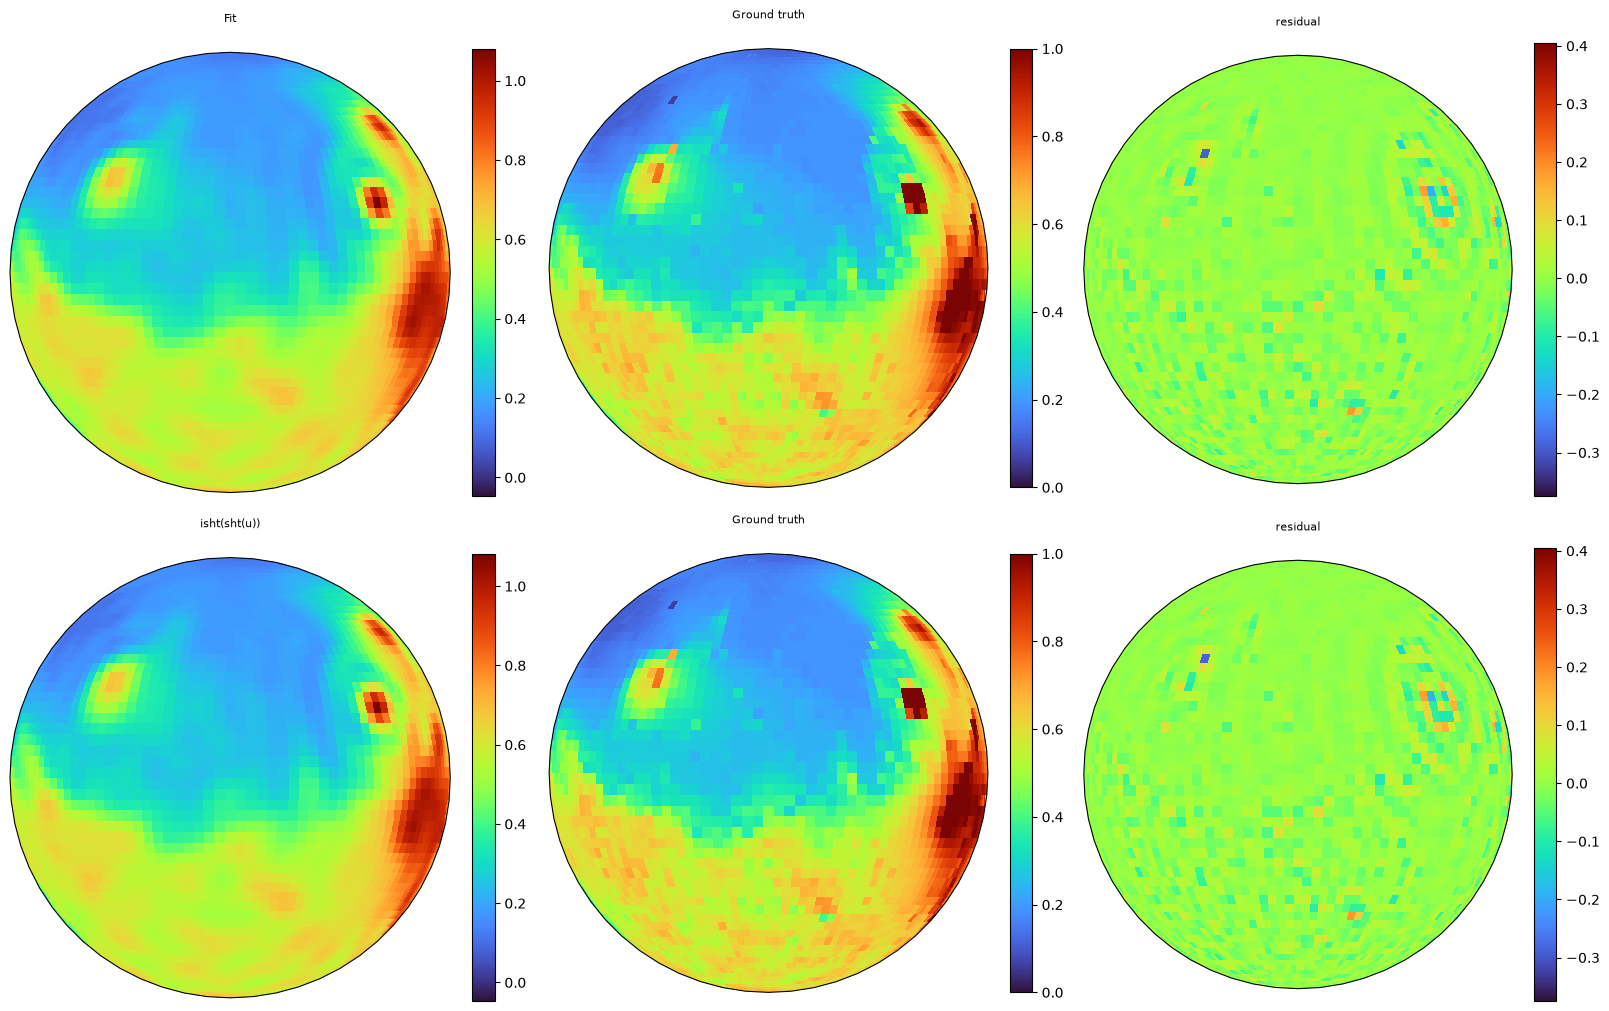

In [16]:
fig = plt.figure(figsize=(16, 10), layout='constrained')
subfigs = fig.subfigures(2, 3)

plot_sphere(isht(theta).detach(), fig=subfigs[0,0], projection="orthographic", cmap="turbo", colorbar=True, title="Fit")
plot_sphere(data, fig=subfigs[0,1], projection="orthographic", cmap="turbo", colorbar=True, title="Ground truth")
plot_sphere((isht(theta) - data).detach(), fig=subfigs[0,2], projection="orthographic", cmap="turbo", colorbar=True, title="residual")

plot_sphere(isht(sht(data)).detach(), fig=subfigs[1,0], projection="orthographic", cmap="turbo", colorbar=True, title="isht(sht(u))")
plot_sphere(data, fig=subfigs[1,1], projection="orthographic", cmap="turbo", colorbar=True, title="Ground truth")
plot_sphere((isht(sht(data)) - data).detach(), fig=subfigs[1,2], projection="orthographic", cmap="turbo", colorbar=True, title="residual")